# RQ3: Identifiability in Baidu-ULTR

In this notebook we generate the plots used in our paper for RQ3, change folder paths when attempting to show results for a different result folder. We also include a result for running identifiability testing for a model trained on 10 positions rather than 20 for Baidu-ULTR. 

In [1]:
import os

# change directory one up 
os.chdir('..')


In [2]:
import importlib
import utils
importlib.reload(utils)
from notebooks.utils import *

In [3]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/Baidu_ULTR_position/baidu_subset=train_Baidu_ULTRA_part1.npz,data=Custom_dataset_deep,experiment=Baidu_ULTR_position,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"

# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

# Load relevance
rel_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_relevance,
    'relevance_shift',
    'param_idx'
)

data = np.load("../ltr_datasets/train_Baidu_ULTRA_part1.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)



['test_clicks_param_shift_0.0_idx21.csv', 'test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-3.0_idx17.csv', 'test_clicks_param_shift_-3.0_idx16.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx20.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_-3.0_idx14.csv', 'test_clicks_param_shift_-3.0_idx15.csv', 'test_clicks_param_shift_-1.5_idx13.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-1.5_idx17.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_-1.5_idx16.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_0.0_idx18.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-1.5_idx14.csv', 'test_clic

In [4]:

from scipy.stats import chi2

# Compute global delta loss first
baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]
perf_df.dropna(inplace=True)
def compute_identifiability(df, thresholds=[0.05, 0.001, 0.0001]):
    required = {
        'relevance_shift', 'param_idx', 'loss',
        'sample_count', 'delta_loss', 'delta_loss_times_samples'
    }
    if not required.issubset(df.columns):
        raise ValueError(f"Missing columns: {required - set(df.columns)}")

    model_threshold = 0.05/df.param_idx.nunique()
    full_identifiability = True

    chi2_critical = {thr: chi2.ppf(1 - thr, df=1) for thr in thresholds}

    # Precompute minimal p-value per row
    df = df.copy()
    df["min_pval"] = np.inf
    for thr, crit in chi2_critical.items():
        mask = df["delta_loss_times_samples"] >= crit
        df.loc[mask, "min_pval"] = np.minimum(df.loc[mask, "min_pval"], thr)

    def first_identifiable(sub, sign):
        s = sub[sub["relevance_shift"] * sign > 0]
        if s.empty:
            return None, None
        s = s.sort_values("relevance_shift", ascending=(sign > 0))
        s = s[s["min_pval"] < np.inf]
        if s.empty:
            return None, None
        row = s.iloc[0]
        return row["min_pval"], row["relevance_shift"]

    results = {}


    print(f"{'Param':>5} | {'Neg p':>7} | {'Neg Δ':>7} | {'Pos Δ':>7} | "
          f"{'Avg ΔLoss':>10} | {'Samples':>8} | {'Conclusion':>22}")
    print("-" * 95)

    for param, sub in df.groupby("param_idx"):
        neg_thr, neg_shift = first_identifiable(sub, sign=-1)
        pos_thr, pos_shift = first_identifiable(sub, sign=+1)
        if (neg_thr is None) or (pos_thr is None):
            full_identifiability = False
        elif min(neg_thr, pos_thr) > model_threshold or (neg_thr is None) or (pos_thr is None):
            full_identifiability = False

        avg_delta = (
            sub["delta_loss_times_samples"].sum() /
            sub["sample_count"].sum()
        )
        total_samples = sub["sample_count"].sum()

        if neg_thr is None and pos_thr is None:
            conclusion = "unidentified"
        elif neg_thr is not None and pos_thr is not None:
            conclusion = "identified"
        else:
            conclusion = "practically unidentified"

        max_delta = sub["delta_loss"].max()

        results[param] = (
            (neg_thr, pos_thr),
            (neg_shift, pos_shift),
            max_delta,
            total_samples,
            conclusion
        )

        print(f"{param:>5} | {str(neg_thr):>7} | {str(neg_shift):>7} | "
              f"{str(pos_shift):>7} | {max_delta:>10.6f} | "
              f"{total_samples:>9} | {conclusion:>22}")


    if full_identifiability:
        print(f"Final Model conclusion: The model is identified with a bonferroni-corrected p-value of 0.05.")
    else:
        print(f"Final Model conclusion: The model is not found to be identified.")

    return results

# Usage
identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])




Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     3.0 |   0.001853 | 2501090.0 |             identified
    1 |  0.0001 |    -1.5 |     3.0 |   0.001022 | 2430155.0 |             identified
    2 |  0.0001 |    -1.5 |     3.0 |   0.000301 | 2575640.0 |             identified
    3 |  0.0001 |    -3.0 |     3.0 |   0.000391 | 2570180.0 |             identified
    4 |  0.0001 |    -3.0 |     3.0 |   0.003672 | 2595790.0 |             identified
    5 |  0.0001 |    -1.5 |    None |   0.002680 | 2624070.0 | practically unidentified
    6 |  0.0001 |    -3.0 |     1.5 |   0.000660 | 2745480.0 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.001908 | 2606895.0 |             identified
    8 |  0.0001 |    -1.5 |    None |   0.000839 | 2782795.0 | practically unidentified
    9 |  0.0001 |    -1.5 |    None |   0

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_37552/2436203616.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


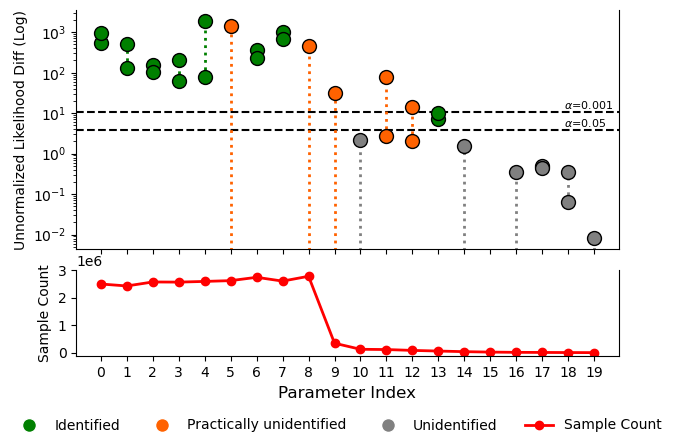

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from matplotlib.ticker import MaxNLocator

def plot_identifiability_summary(
    identifiability_results,
    perf_df,
    *,
    output_path=None,
    x_tick_rotation=0,
    figsize=(7, 4.5),
    comparison_lines=((3.84, f"$\\alpha$=0.05"), (10.83, f"$\\alpha$=0.001")),
    color_map=None,
    sample_count_color="#FF0000",
):
    if color_map is None:
        color_map = {
            "identified": "green",
            "practically unidentified": "#FF6200",
            "unidentified": "gray",
        }

    # -----------------------
    # Extract per-parameter data
    # -----------------------
    params = sorted(identifiability_results.keys())
    sample_counts = [identifiability_results[p][3] for p in params]
    conclusions = [identifiability_results[p][4].strip().lower() for p in params]
    dot_colors = [color_map[c] for c in conclusions]

    # -----------------------
    # Δ Loss × Sample Count (signed)
    # -----------------------
    neg_df = perf_df[perf_df["relevance_shift"] < 0]
    pos_df = perf_df[perf_df["relevance_shift"] > 0]

    delta_loss_times_samples_neg = (
        neg_df.assign(stat=lambda d: d.delta_loss * d.sample_count)
            .groupby("param_idx")["stat"]
            .max()
    )

    delta_loss_times_samples_pos = (
        pos_df.assign(stat=lambda d: d.delta_loss * d.sample_count)
            .groupby("param_idx")["stat"]
            .max()
    )
    delta_loss_times_samples_neg = [
        delta_loss_times_samples_neg.get(p, 0) for p in params
    ]
    delta_loss_times_samples_pos = [
        delta_loss_times_samples_pos.get(p, 0) for p in params
    ]

    # -----------------------
    # Figure layout
    # -----------------------
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 0.9], "hspace": 0.13},
    )

    # =========================
    # TOP PANEL
    # =========================
    ax_top.set_yscale("log")

    for i, p in enumerate(params):
        y_neg = delta_loss_times_samples_neg[i]
        y_pos = delta_loss_times_samples_pos[i]
        color = dot_colors[i]

        ax_top.vlines(
            x=p,
            ymin=min(y_neg, y_pos),
            ymax=max(y_neg, y_pos),
            color=color,
            linewidth=2,
            linestyle=":",
        )

        ax_top.scatter(
            p,
            y_neg,
            color=color,
            edgecolor="black",
            s=100,
            linewidth=1,
            zorder=3,
        )
        ax_top.scatter(
            p,
            y_pos,
            color=color,
            edgecolor="black",
            s=100,
            linewidth=1,
            zorder=3,
        )

    ax_top.set_ylabel(f"Unnormalized Likelihood Diff (Log)", fontsize=10)

    for yval, label in comparison_lines:
        ax_top.axhline(y=yval, color="black", ls="--", lw=1.5, zorder=1)
        ax_top.text(
            max(params) * 0.94,
            yval * 1.05,
            label,
            ha="left",
            va="bottom",
            fontsize=8,
        )

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(True)

    # =========================
    # BOTTOM PANEL
    # =========================
    ax_bottom.plot(
        params,
        sample_counts,
        color=sample_count_color,
        marker="o",
        linewidth=2,
        label="Sample Count",
    )
    ax_bottom.set_ylabel(
        "Sample Count",
        color="black",
        fontsize=10,
    )
    ax_bottom.tick_params(axis="y", colors="black")

    # Force more yticks
    yticks = [0, 1e6, 2e6, 3e6]
    ax_bottom.set_yticks(yticks)

    ax_bottom.set_xlabel("Parameter Index", fontsize=12)
    ax_bottom.set_xticks(params)
    ax_bottom.set_xticklabels(params, rotation=x_tick_rotation)
    ax_bottom.spines["top"].set_visible(False)

    # =========================
    # LEGEND
    # =========================
    legend_ident = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markersize=10,
            label=label.capitalize(),
        )
        for label, color in color_map.items()
    ]

    # Legend: color dots + sample count
    legend_elements = legend_ident + [
        Line2D(
            [0],
            [0],
            color=sample_count_color,
            lw=2,
            marker="o",
            label="Sample Count",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.00),
        ncol=4,
        frameon=False,
    )

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.05)

    plt.show()

    return fig, (ax_top, ax_bottom)


_, _ =plot_identifiability_summary(
    identifiability_results,
    perf_df,
    output_path="notebooks/plots/position_bias_Identifiability_BaiduULTRA.pdf",
)

['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-3.0_idx12.csv', 'test_clicks_param_shift_-1.5_idx9.csv', 'test_clicks_param_shift_-1.5_idx8.csv', 'test_clicks_param_shift_3.0_idx8.csv', 'test_clicks_param_shift_0.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx7.csv', 'test_clicks_param_shift_1.5_idx7.csv', 'test_clicks_param_shift_1.5_idx6.csv', 'test_clicks_param_shift_-3.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx4.csv', 'test_clicks_param_shift_1.5_idx4.csv', 'test_clicks_param_shi

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_37552/2436203616.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


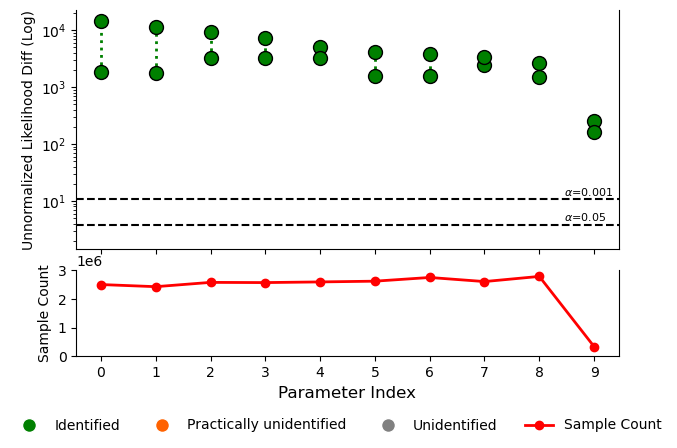

In [6]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/Baidu_ULTR_position/baidu_subset=train_Baidu_ULTRA_very_short.npz,data=Custom_dataset_deep,experiment=Baidu_ULTR_position,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"

# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

data = np.load("../ltr_datasets/train_Baidu_ULTRA_very_short.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)

baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]
perf_df.dropna(inplace=True)


identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])

_, _ =plot_identifiability_summary(
    identifiability_results,
    perf_df,
    output_path="notebooks/plots/position_bias_Identifiability_BaiduULTRA_short.pdf",
)
